# TrOCR: Transformer-based Optical Character Recognition

## What is TrOCR?

TrOCR (Transformer-based OCR) is a revolutionary approach to text recognition developed by Microsoft Research. Unlike traditional OCR methods that use CNN+RNN combinations, TrOCR leverages the power of **pure Transformer architecture** for both image understanding and text generation.

### Key Innovation:
- **No CNN/RNN**: Uses Vision Transformer (ViT) for image encoding
- **No CTC Loss**: Uses autoregressive text generation like GPT
- **End-to-End**: Direct image-to-text transformation
- **Pre-trained**: Leverages large-scale pre-trained models

### Architecture Overview:
```
Input Image → Vision Transformer (Encoder) → Text Transformer (Decoder) → Output Text
```

## Traditional OCR vs TrOCR Comparison

### Traditional OCR (CRNN + CTC):
```
Image → CNN (spatial features) → RNN (sequence modeling) → CTC (alignment) → Text
```
### TrOCR Approach:
```
Image → Vision Transformer → Text Transformer → Text
```

## TrOCR Architecture Deep Dive

### 1. Vision Transformer Encoder
- **Input**: Text image (e.g., 384×384 pixels)
- **Process**: Splits image into patches (e.g., 16×16 patches)
- **Output**: Sequence of visual tokens representing image content
- **Pre-training**: Uses models like DeiT (Data-efficient image Transformers)

### 2. Text Transformer Decoder
- **Input**: Visual tokens from encoder + previous generated text
- **Process**: Autoregressive text generation (like GPT)
- **Output**: Next character/word prediction
- **Pre-training**: Uses models like RoBERTa

### 3. Training Strategy
**Stage 1: Pre-training**
- Large-scale synthetic data (674M text images)
- Learn general text recognition capabilities

**Stage 2: Fine-tuning**
- Specific datasets (printed/handwritten)
- Task-specific optimization

### 4. Key Components
- **Encoder**: DeiT-Base or DeiT-Large
- **Decoder**: RoBERTa-Base or RoBERTa-Large
- **Connection**: Cross-attention between vision and text

In [1]:
# Install required packages
!pip install transformers pillow requests torch torchvision

# Import necessary libraries
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np

print("✅ All dependencies installed successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🤗 Transformers library ready for TrOCR!")

✅ All dependencies installed successfully!
🔥 PyTorch version: 2.10.0+cpu
🤗 Transformers library ready for TrOCR!


## Basic TrOCR Usage

### Available Pre-trained Models:
1. **microsoft/trocr-base-printed**: For printed text
2. **microsoft/trocr-base-handwritten**: For handwritten text
3. **microsoft/trocr-large-printed**: Larger model for printed text
4. **microsoft/trocr-large-handwritten**: Larger model for handwritten text

### Basic Workflow:
1. Load pre-trained model and processor
2. Preprocess image
3. Generate text prediction
4. Decode result

In [2]:
# Load TrOCR model for handwritten text
print("📦 Loading TrOCR model and processor...")

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

print("✅ Model loaded successfully!")
print(f"📊 Model type: {type(model).__name__}")
print(f"🔍 Processor type: {type(processor).__name__}")

# Model architecture overview
print("\n🏗️ Model Architecture:")
print(f"   Encoder: {model.encoder.__class__.__name__}")
print(f"   Decoder: {model.decoder.__class__.__name__}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

📦 Loading TrOCR model and processor...


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded successfully!
📊 Model type: VisionEncoderDecoderModel
🔍 Processor type: TrOCRProcessor

🏗️ Model Architecture:
   Encoder: ViTModel
   Decoder: TrOCRForCausalLM
   Total parameters: 333,921,792


📝 Demo 1: Handwritten Text Recognition


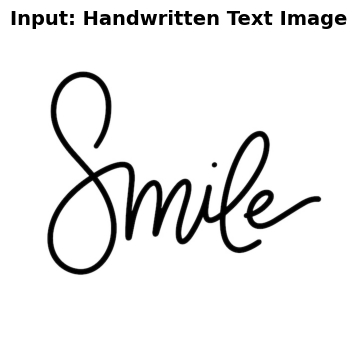

🔄 Processing image...
📐 Input tensor shape: torch.Size([1, 3, 384, 384])
🧠 Generating text...

📜 Recognition Result:
   Predicted Text: 'smile .'
   Length: 7 characters


In [3]:
# Demo 1: Handwritten text recognition
print("📝 Demo 1: Handwritten Text Recognition")

# Load a random handwritten text image
url = "https://img.freepik.com/premium-vector/smile-inscription-handwriting-one-word-smile-isolated-white-background-lettering-word-smile_112545-5387.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Display the image
plt.figure(figsize=(12, 4))
plt.imshow(image)
plt.axis('off')
plt.title("Input: Handwritten Text Image", fontsize=14, fontweight='bold')
plt.show()

# Process the image
print("🔄 Processing image...")
pixel_values = processor(image, return_tensors="pt").pixel_values
print(f"📐 Input tensor shape: {pixel_values.shape}")

# Generate text
print("🧠 Generating text...")
generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("\n📜 Recognition Result:")
print(f"   Predicted Text: '{generated_text}'")
print(f"   Length: {len(generated_text)} characters")

🖨️ Demo 2: Printed Text Recognition
📦 Loading printed text model...


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

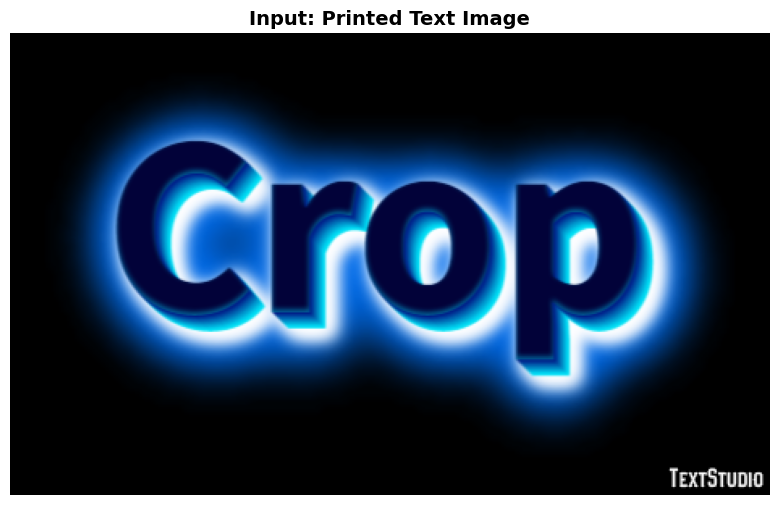


📜 Recognition Result:
   Predicted Text: 'CROP'


In [4]:
# Demo 2: Printed text recognition
print("🖨️ Demo 2: Printed Text Recognition")

# Load printed text model
print("📦 Loading printed text model...")
processor_printed = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
model_printed = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")

# Create a simple printed text image (you can replace with your own)
# For demo, we'll use a sample receipt image
url_printed = "https://cdn.textstudio.com/output/sample/normal/0/9/9/4/crop-logo-275-14990.png"
try:
    image_printed = Image.open(requests.get(url_printed, stream=True).raw).convert("RGB")

    # Display the image
    plt.figure(figsize=(10, 6))
    plt.imshow(image_printed)
    plt.axis('off')
    plt.title("Input: Printed Text Image", fontsize=14, fontweight='bold')
    plt.show()

    # Process and recognize
    pixel_values_printed = processor_printed(image_printed, return_tensors="pt").pixel_values
    generated_ids_printed = model_printed.generate(pixel_values_printed)
    generated_text_printed = processor_printed.batch_decode(generated_ids_printed, skip_special_tokens=True)[0]

    print("\n📜 Recognition Result:")
    print(f"   Predicted Text: '{generated_text_printed}'")

except Exception as e:
    print(f"❌ Could not load demo image: {e}")
    print("💡 You can replace the URL with your own printed text image!")

## Advanced TrOCR Features

### 1. Batch Processing
Process multiple images at once for better efficiency.

### 2. Custom Generation Parameters
Control text generation with parameters like:
- `max_length`: Maximum output length
- `num_beams`: Beam search width
- `early_stopping`: Stop when EOS token is generated

### 3. Fine-tuning
Adapt TrOCR to your specific domain or language.

In [5]:
# Batch processing multiple images
print("📦 Batch Processing Demo")

# For demo, we'll process the same image multiple times
# In practice, you would have different images
images = [image, image, image]  # Replace with your own image list

print(f"🔢 Processing {len(images)} images in batch...")

# Process all images at once
pixel_values_batch = processor(images, return_tensors="pt").pixel_values
print(f"📐 Batch tensor shape: {pixel_values_batch.shape}")

# Generate text for all images
generated_ids_batch = model.generate(pixel_values_batch)
generated_texts_batch = processor.batch_decode(generated_ids_batch, skip_special_tokens=True)

print("\n📋 Batch Results:")
for i, text in enumerate(generated_texts_batch):
    print(f"   Image {i+1}: '{text}'")

print(f"\n⚡ Processed {len(images)} images successfully!")

📦 Batch Processing Demo
🔢 Processing 3 images in batch...
📐 Batch tensor shape: torch.Size([3, 3, 384, 384])

📋 Batch Results:
   Image 1: 'smile .'
   Image 2: 'smile .'
   Image 3: 'smile .'

⚡ Processed 3 images successfully!


## Practical Tips for Using TrOCR

### 1. Image Preprocessing
- **Resolution**: Higher resolution images generally work better
- **Contrast**: Ensure good contrast between text and background
- **Orientation**: Images should be properly oriented
- **Cropping**: Crop to focus on text regions

### 2. Model Selection
- **Printed text**: Use `trocr-base-printed` or `trocr-large-printed`
- **Handwritten text**: Use `trocr-base-handwritten` or `trocr-large-handwritten`
- **Mixed content**: Try both models and choose better result
- **Performance vs Speed**: Base models are faster, Large models are more accurate

### 3. Generation Parameters
- **num_beams=5**: Good balance of quality and speed
- **early_stopping=True**: Prevents unnecessary computation
- **max_length**: Set based on expected text length

### 4. Error Handling
- Always check image format (RGB)
- Handle network errors when loading models
- Validate generation results

In [6]:
# Robust TrOCR function with error handling
def robust_trocr_ocr(image_path_or_url, text_type="handwritten", **generation_kwargs):
    """
    Robust TrOCR function with error handling and best practices.

    Args:
        image_path_or_url (str): Path to image file or URL
        text_type (str): "handwritten" or "printed"
        **generation_kwargs: Additional generation parameters

    Returns:
        dict: Results with text, confidence, and metadata
    """
    try:
        # Load appropriate model
        if text_type == "handwritten":
            model_name = "microsoft/trocr-base-handwritten"
        elif text_type == "printed":
            model_name = "microsoft/trocr-base-printed"
        else:
            raise ValueError("text_type must be 'handwritten' or 'printed'")

        print(f"📦 Loading {text_type} model: {model_name}")
        processor = TrOCRProcessor.from_pretrained(model_name)
        model = VisionEncoderDecoderModel.from_pretrained(model_name)

        # Load image
        if image_path_or_url.startswith("http"):
            print(f"🌐 Loading image from URL...")
            image = Image.open(requests.get(image_path_or_url, stream=True).raw)
        else:
            print(f"📁 Loading image from file...")
            image = Image.open(image_path_or_url)

        # Ensure RGB format
        image = image.convert("RGB")

        # Set default generation parameters
        default_params = {
            "num_beams": 5,
            "early_stopping": True,
            "max_length": 50
        }
        default_params.update(generation_kwargs)

        # Process and generate
        print(f"🔄 Processing with parameters: {default_params}")
        pixel_values = processor(image, return_tensors="pt").pixel_values
        generated_ids = model.generate(pixel_values, **default_params)
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        # Return results
        result = {
            "text": generated_text,
            "length": len(generated_text),
            "model_used": model_name,
            "image_size": image.size,
            "generation_params": default_params,
            "success": True
        }

        print(f"✅ OCR completed successfully!")
        return result

    except Exception as e:
        print(f"❌ Error during OCR: {str(e)}")
        return {
            "text": "",
            "error": str(e),
            "success": False
        }

# Test the robust function
print("🧪 Testing Robust TrOCR Function\n")

# Test with handwritten text
result = robust_trocr_ocr(
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ5b9qa1KsWgSKE2GyaZBCIjzVn6At7YA3fKw&s",
    text_type="printed"
)

if result["success"]:
    print(f"📜 Recognized Text: '{result['text']}'")
    print(f"📊 Metadata: {result}")
else:
    print(f"❌ OCR Failed: {result['error']}")

🧪 Testing Robust TrOCR Function

📦 Loading printed model: microsoft/trocr-base-printed


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🌐 Loading image from URL...
🔄 Processing with parameters: {'num_beams': 5, 'early_stopping': True, 'max_length': 50}
✅ OCR completed successfully!
📜 Recognized Text: 'SMILE'
📊 Metadata: {'text': 'SMILE', 'length': 5, 'model_used': 'microsoft/trocr-base-printed', 'image_size': (299, 168), 'generation_params': {'num_beams': 5, 'early_stopping': True, 'max_length': 50}, 'success': True}


## Limitations and Considerations

### Limitations:
1. **Computational Requirements**: Needs more GPU memory than CRNN
2. **Speed**: Slower inference compared to lightweight CNN+RNN models
3. **Model Size**: Larger models require more storage
4. **Language Support**: Pre-trained models mainly support English
5. **Layout Dependency**: Works best on single-line or simple multi-line text

### When NOT to Use TrOCR:
- **Real-time applications** with strict latency requirements
- **Edge devices** with limited computational resources
- **Large-scale batch processing** where speed is critical
- **Simple printed text** where CRNN+CTC might suffice

### Best Practices:
1. **Choose the right model**: Base vs Large based on your requirements
2. **Preprocess images**: Ensure good quality and proper orientation
3. **Batch processing**: Use batches for multiple images
4. **GPU utilization**: Use GPU for better performance
5. **Error handling**: Implement robust error handling for production use

### Resources:
- 📚 [TrOCR Paper](https://arxiv.org/abs/2109.10282)
- 🔗 [Microsoft TrOCR GitHub](https://github.com/microsoft/unilm/tree/master/trocr)
- 🤗 [HuggingFace TrOCR Docs](https://huggingface.co/docs/transformers/model_doc/trocr)
- 💻 [Fine-tuning Tutorial](https://huggingface.co/blog/trocr)

**Happy OCR-ing with TrOCR! 🚀**